In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("CO2 Emissions.csv")

print(df.head())

print("Dataset Shape:", df.shape)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nStatistical Summary:")
print(df.describe())

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("CO2 Emissions.csv")

print(df.shape)
print(df.head())

(7385, 12)
    Make       Model Vehicle Class  Engine Size(L)  Cylinders Transmission  \
0  ACURA         ILX       COMPACT             2.0          4          AS5   
1  ACURA         ILX       COMPACT             2.4          4           M6   
2  ACURA  ILX HYBRID       COMPACT             1.5          4          AV7   
3  ACURA     MDX 4WD   SUV - SMALL             3.5          6          AS6   
4  ACURA     RDX AWD   SUV - SMALL             3.5          6          AS6   

  Fuel Type  Fuel Consumption City (L/100 km)  \
0         Z                               9.9   
1         Z                              11.2   
2         Z                               6.0   
3         Z                              12.7   
4         Z                              12.1   

   Fuel Consumption Hwy (L/100 km)  Fuel Consumption Comb (L/100 km)  \
0                              6.7                               8.5   
1                              7.7                               9.6   
2        

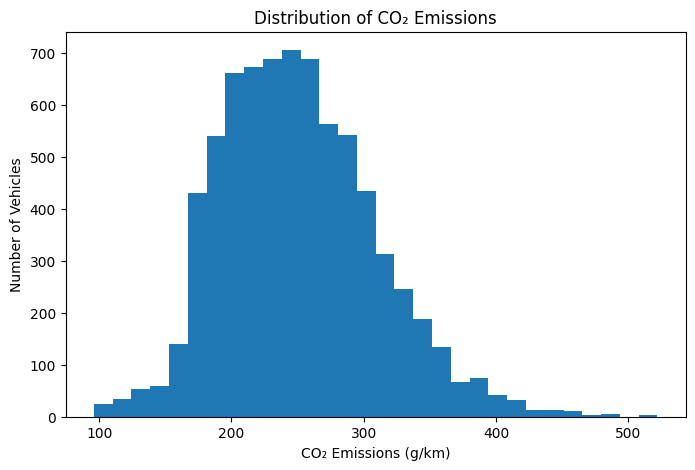

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df["CO2 Emissions(g/km)"],
    bins=30
)

plt.xlabel("CO₂ Emissions (g/km)")
plt.ylabel("Number of Vehicles")
plt.title("Distribution of CO₂ Emissions")

plt.show()

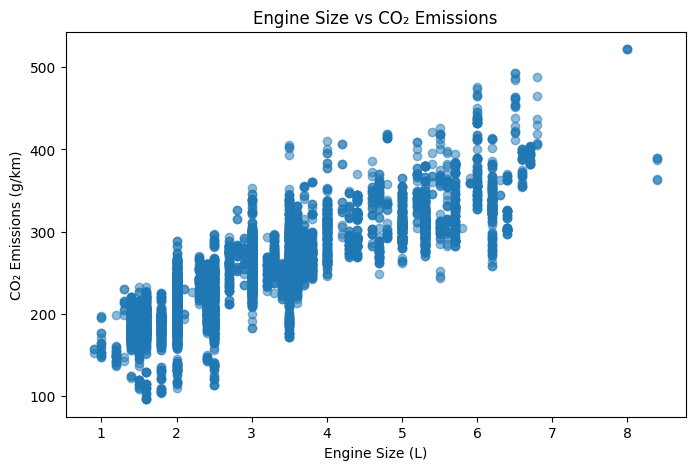

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(
    df["Engine Size(L)"],
    df["CO2 Emissions(g/km)"],
    alpha=0.5
)

plt.xlabel("Engine Size (L)")
plt.ylabel("CO₂ Emissions (g/km)")
plt.title("Engine Size vs CO₂ Emissions")
plt.show()

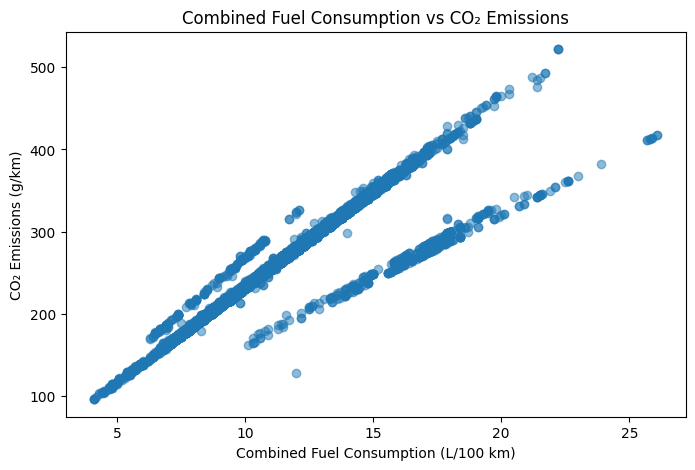

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(
    df["Fuel Consumption Comb (L/100 km)"],
    df["CO2 Emissions(g/km)"],
    alpha=0.5
)

plt.xlabel("Combined Fuel Consumption (L/100 km)")
plt.ylabel("CO₂ Emissions (g/km)")
plt.title("Combined Fuel Consumption vs CO₂ Emissions")
plt.show()

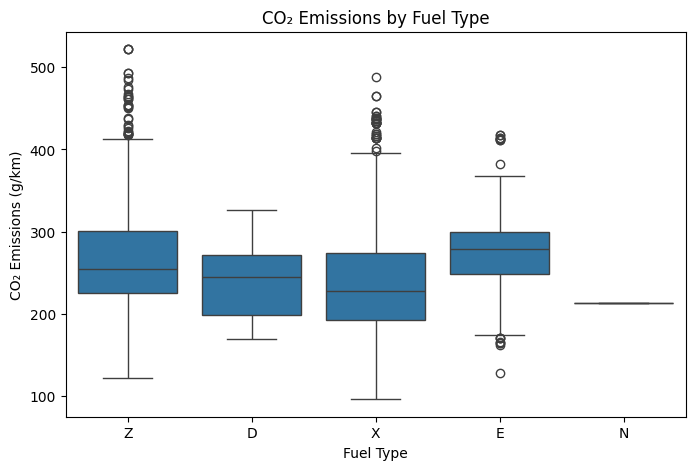

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(
    x="Fuel Type",
    y="CO2 Emissions(g/km)",
    data=df
)

plt.xlabel("Fuel Type")
plt.ylabel("CO₂ Emissions (g/km)")
plt.title("CO₂ Emissions by Fuel Type")
plt.show()

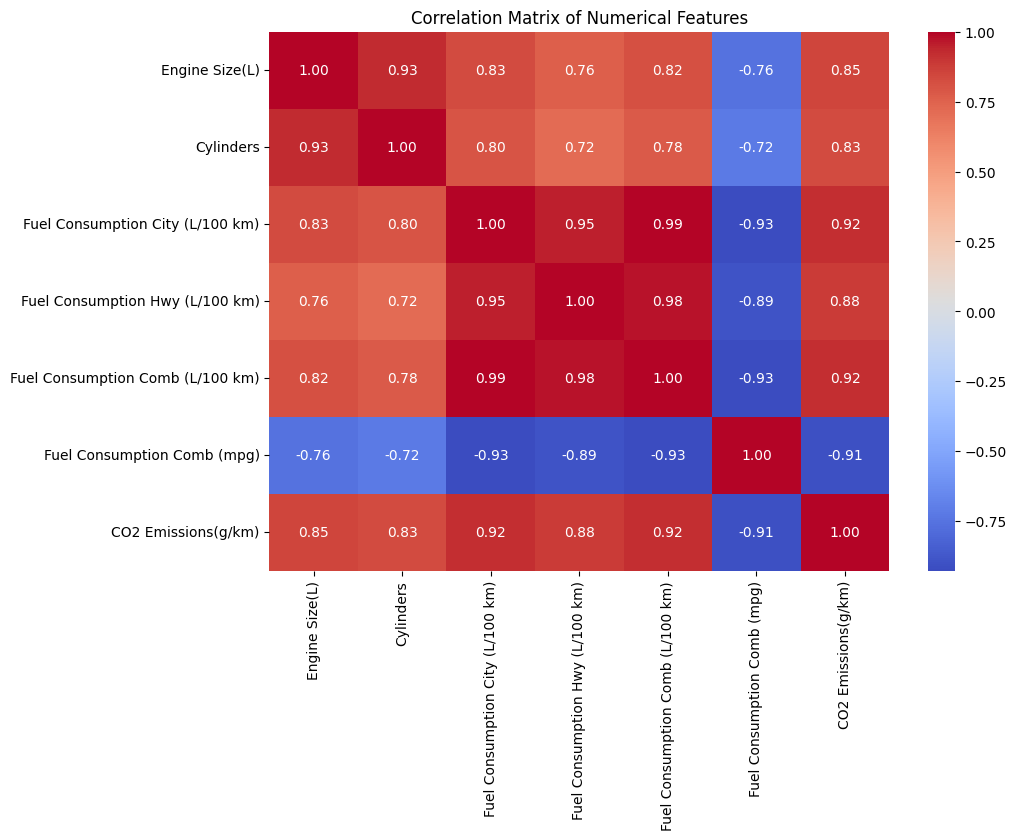

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,7))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()


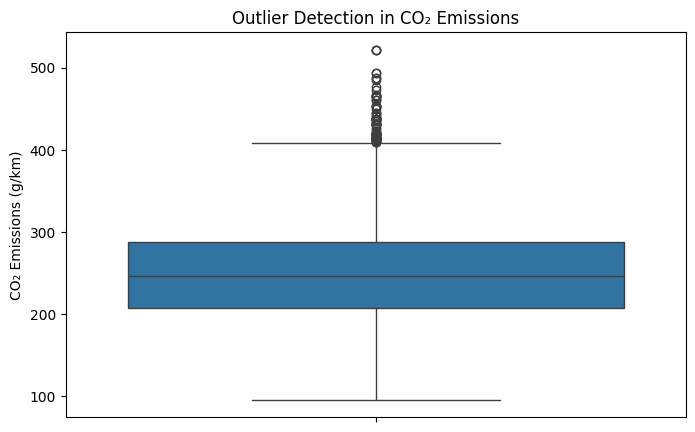

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(
    y=df["CO2 Emissions(g/km)"]
)

plt.ylabel("CO₂ Emissions (g/km)")
plt.title("Outlier Detection in CO₂ Emissions")
plt.show()

In [ ]:


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression


target = "CO2 Emissions(g/km)"

X = df.drop(columns=[target])
y = df[target]


categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns


preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)


model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


model.fit(X_train, y_train)


y_pred = model.predict(X_test)

print("Model trained successfully!")
print("Prediction completed successfully!")

Model trained successfully!
Prediction completed successfully!


In [ ]:


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Model Evaluation Results
------------------------
Mean Absolute Error (MAE): 3.241923706469123
Mean Squared Error (MSE): 29.933539279890656
Root Mean Squared Error (RMSE): 5.471155205246023
R² Score: 0.9912974471730829


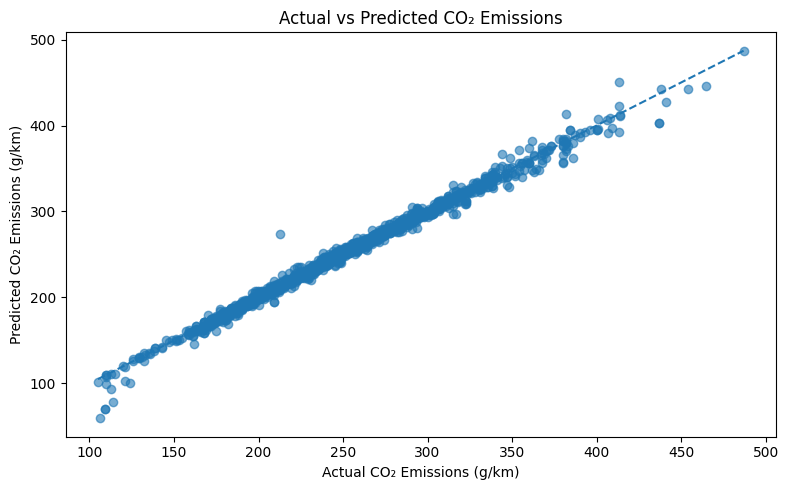

In [ ]:


import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred, alpha=0.6)


plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual CO₂ Emissions (g/km)")
plt.ylabel("Predicted CO₂ Emissions (g/km)")
plt.title("Actual vs Predicted CO₂ Emissions")

plt.tight_layout()
plt.show()

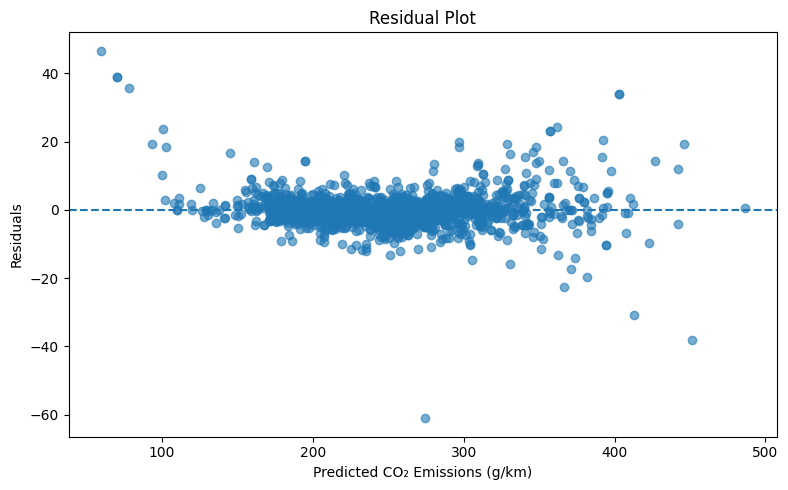

In [ ]:


import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals, alpha=0.6)


plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted CO₂ Emissions (g/km)")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.tight_layout()
plt.show()